# Stroke Prediction Using Machine Learning






## Setup & Dataset
This project uses the **Stroke Prediction Dataset** by Fedesoriano

**Dataset Source**:

[Stroke Prediction Dataset - Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

**Instruction (Google Colab)**:
1. Download the dataset from Kaggle
2. Extract the downloaded ZIP file
3. Upload the file 'healthcare-dataset-stroke-data.csv' to the Google Colab working  directory
4. Run the next cell

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Handling imbalance data
from imblearn.over_sampling import SMOTE

# Machine learning
from sklearn import metrics
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_curve, auc

In [ ]:
# Load Dataset
df=pd.read_csv('healthcare-dataset-stroke-data.csv')


In [ ]:
# Melihat struktur awal dataset

# Menampilkan 5 baris pertama secara default untuk verifikasi awal bahwa data berhasil di muat dengan benar
print(df.head())

# menampilkan 5 baris data terakhir untuk memastikan tidak ada data yang kosong atau amomali di akhir file
print('\n5 Data terbawah:')
print(df.tail())


5 Data teratas:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

5 Data terbawah:
         id  gender   

In [ ]:
# Identify the shape of dataset
df.shape

(5110, 12)

In [ ]:
# Get the list of columns
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [ ]:
# Identify datatype of each columns
# Mengembalikan tipe data setiap kolom
df.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [ ]:
# Get basic dataset information
# Menampilkan ringkasan lengkap — jumlah baris, kolom, tipe data,
# dan jumlah non-null values sekaligus — berguna untuk deteksi missing value awal
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
# Mengembalikan jumlah nilai unik per kolom

df.nunique()

,0
id,5110
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,418


In [ ]:
# Menampilkan semua baris yang memiliki duplikat
# keep=false -- semua salinan ditandai, bukan hanya yang kedua
df[df.duplicated(keep=False)]

# Menghitung  total baris yang terduplikasi
df.duplicated().sum()

np.int64(0)

In [ ]:
# Drop kolom id karena tidak mengandung informasi prediktif
# id hanya sebagai identifier unik setiap baris, bukan fitur yang bermakna
# axis=1 artinya menghapus kolom dan axis=0 artinya menghapus baris
df=df.drop('id', axis=1)

In [ ]:
# Identify missing value
# Check the number of missing value in each column
df.isna().sum()

# Menampilkan baris yang berisi missing value dikolom bmi
df[df.bmi.isna()]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...
5039,Male,41.0,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
5048,Male,40.0,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
5093,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
5099,Male,40.0,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


In [ ]:
# Mengisi nilai BMI yang hilang menggunakan mean imputation
# Dataset tidak menyediakan informasi mengenai mekanisme missing value
# Missing value diasumsikan sebagai Missing Completely at Ramdom (MCAR)
# Proporsi data yang hilang relatif kecil (201 dari 5110 observasi, atau sekitar 3,9%)
# Sehingga mean imputation dipilih karena diperkirakan tidak akan mengubah distribusi data secara signifikan

df['bmi'].fillna(df['bmi'].mean(), inplace= True)

/tmp/ipykernel_1972/4167020022.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace= True)


In [ ]:
# Konfirmasi sudah tidak ada lagi missing value
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
# Check distribusi nilai gender
df['gender'].value_counts()

# Hapus baris denan gender'Other'(hanya ada 1 baris tidak signifikan secara statistik)
df=df[df['gender'] !='Other']

# Verifikasi distribusi gender setelah penghapusan
df['gender'].value_counts()


,count
gender,
Female,2994
Male,2115


In [ ]:
# One Hot Encoding for all nominal categorical columns
# Encode all nominal categories without imploying other
# Kolom ini berisi data nominal tidak punya urutan hierarki
df=pd.get_dummies(df, columns=['gender','ever_married','Residence_type','work_type','smoking_status'])

In [ ]:
# Statistical summary to detect anomalies and understand data distribution
# Check min/max for imposible values, mean for reasonableness, std for spread
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5109.0,43.229986,22.613575,0.08,25.00,45.00,61.00,82.00
hypertension,5109.0,0.097475,0.296633,0.00,0.00,0.00,0.00,1.00
heart_disease,5109.0,0.054022,0.226084,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,5109.0,106.140399,45.285004,55.12,77.24,91.88,114.09,271.74
bmi,5109.0,28.894508,7.698235,10.30,23.80,28.40,32.80,97.60
stroke,5109.0,0.048738,0.215340,0.00,0.00,0.00,0.00,1.00


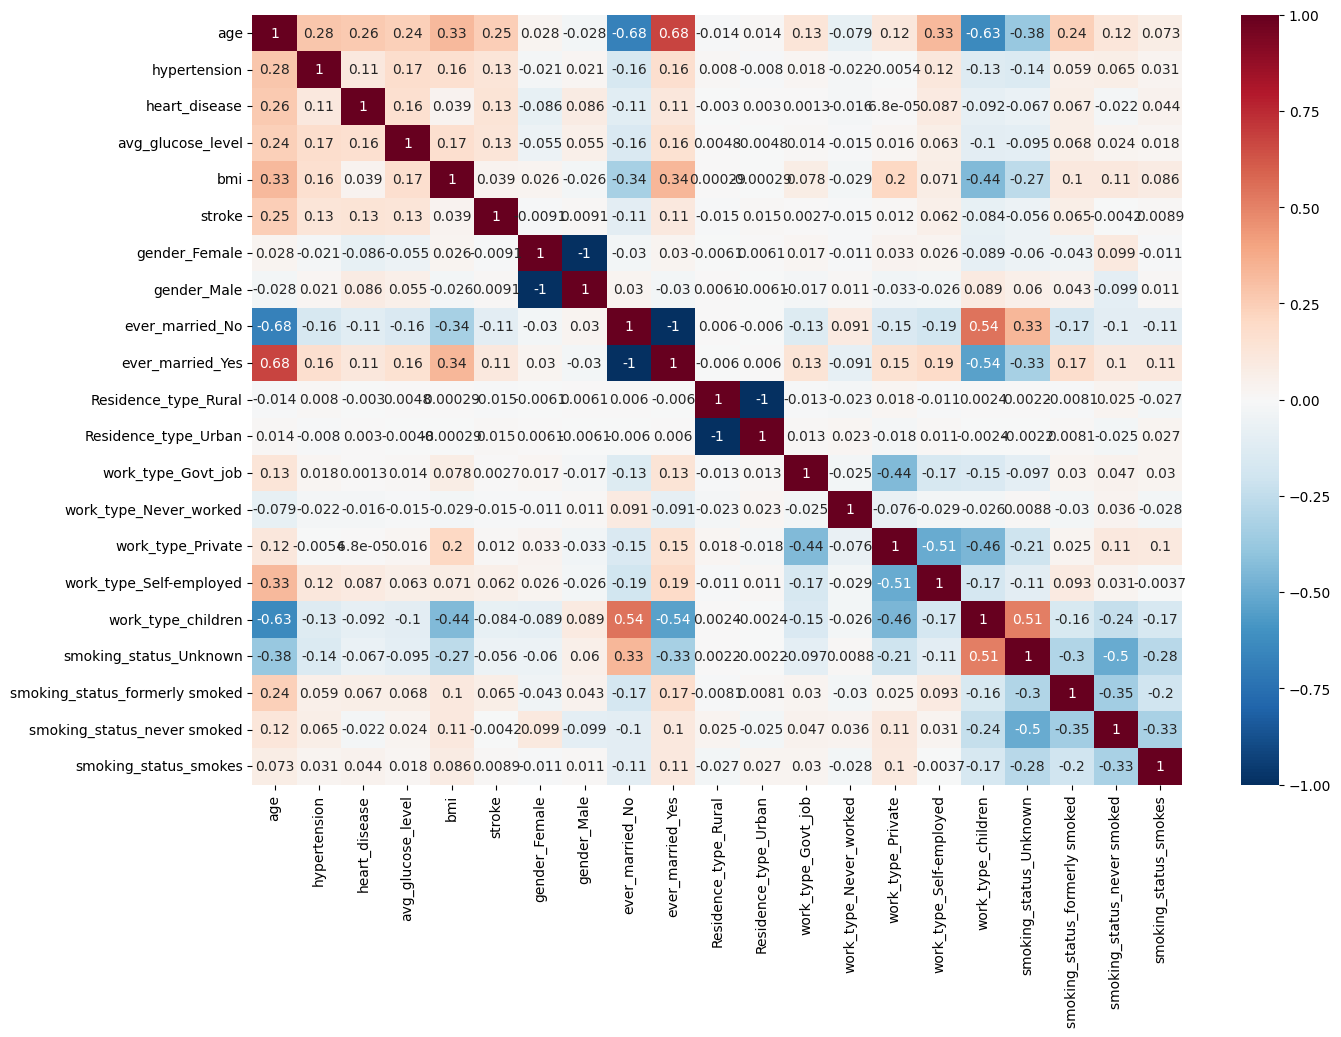

In [ ]:
# Calculate correlation between all numerical columns
df.corr()

# Visualize correlation matrix as heatmap
plt.figure(figsize=(15,10))
corrMatrix=df.corr()
sns.heatmap(corrMatrix,cmap="RdBu_r", annot=True)
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# cmap="RdBu_r" → skema warna Red-Blue reversed:
# Merah → korelasi positif kuat (mendekati +1)
# Biru → korelasi negatif kuat (mendekati -1)
# Putih → tidak ada korelasi (mendekati 0)

# annot=True → tampilkan angka korelasi di dalam setiap kotak.

In [ ]:
# Show correlation of all features with target variable(stroke)
# Tampilkan korelasi semua fitur dengan target(stroke)
print(df.corr()['stroke'].sort_values(ascending=False))


stroke                            1.000000
age                               0.245239
heart_disease                     0.134905
avg_glucose_level                 0.131991
hypertension                      0.127891
ever_married_Yes                  0.108299
smoking_status_formerly smoked    0.064683
work_type_Self-employed           0.062150
bmi                               0.038912
Residence_type_Urban              0.015415
work_type_Private                 0.011927
gender_Male                       0.009081
smoking_status_smokes             0.008920
work_type_Govt_job                0.002660
smoking_status_never smoked      -0.004163
gender_Female                    -0.009081
work_type_Never_worked           -0.014885
Residence_type_Rural             -0.015415
smoking_status_Unknown           -0.055924
work_type_children               -0.083888
ever_married_No                  -0.108299
Name: stroke, dtype: float64


### **Insights**:
1. **Age** adalah variabel yang memiliki korelasi paling kuat dengan stroke
2. **Ever_merried_yes** menunjukan korelasi positif yang lemah dengan stroke(0.11). Corrrelation matrix juga menunjukan bahwa variabel ini memiliki korelasi yang relatif tinggi dengan **age** (0.68). Hal ini mengindikasikan bahwa hubungan antara **ever_merried_yes** dan **stroke** mungkin sebagian dipengaruhi oleh faktor usia, mengingat **age** merupakan variabel yang memiliki korelasi tertinggi dengan stroke pada dataset ini. Namun, analisis ini bersifat korelasional, sehingga tidak dapat memastikan adanya hubungan sebab-akibat maupun membuktikan bahwa **age** benar-benar bertindak sebagai **confounding variable**.

3. **Smoking_status_formerly smoked** (0.064) memiliki korelasi yang sedikit lebih tinggi terhadap **stroke** dibandingkan dengan **smoking_status_smokes** (0.008).Temuan ini menarik, namum belum dapat dijelaskan hanya berdasarkan analisis korelasi. Salah satu kemungkinan yang dapat dijelaskan adalah bahwa
kelompok orang yang pernah merokok memiliki karakteristik yang berbeda, seperti usia dan kondisi kesehatan dibanding kelompok perokok aktif. Namun, proyek ini tidak menganalisis faktor-faktor tersebut, sehingga interpretasi ini masih berupa hipotesis.

> Korelasi ≠ Kausalitas

> Dua hal bisa berkorelasi bukan karena saling menyebabkan, tapi karena keduanya dipengaruhi oleh faktor ketiga yang tersembunyi.

> Korelasi berguna untuk mengidentifikasi pola hubungan antarvariabel, tetapi diperlukan analisis statistik dan kausal lebih lanjut untuk mengetahui apakah hubungan tersebut benar-benar bersifat sebab-akibat.




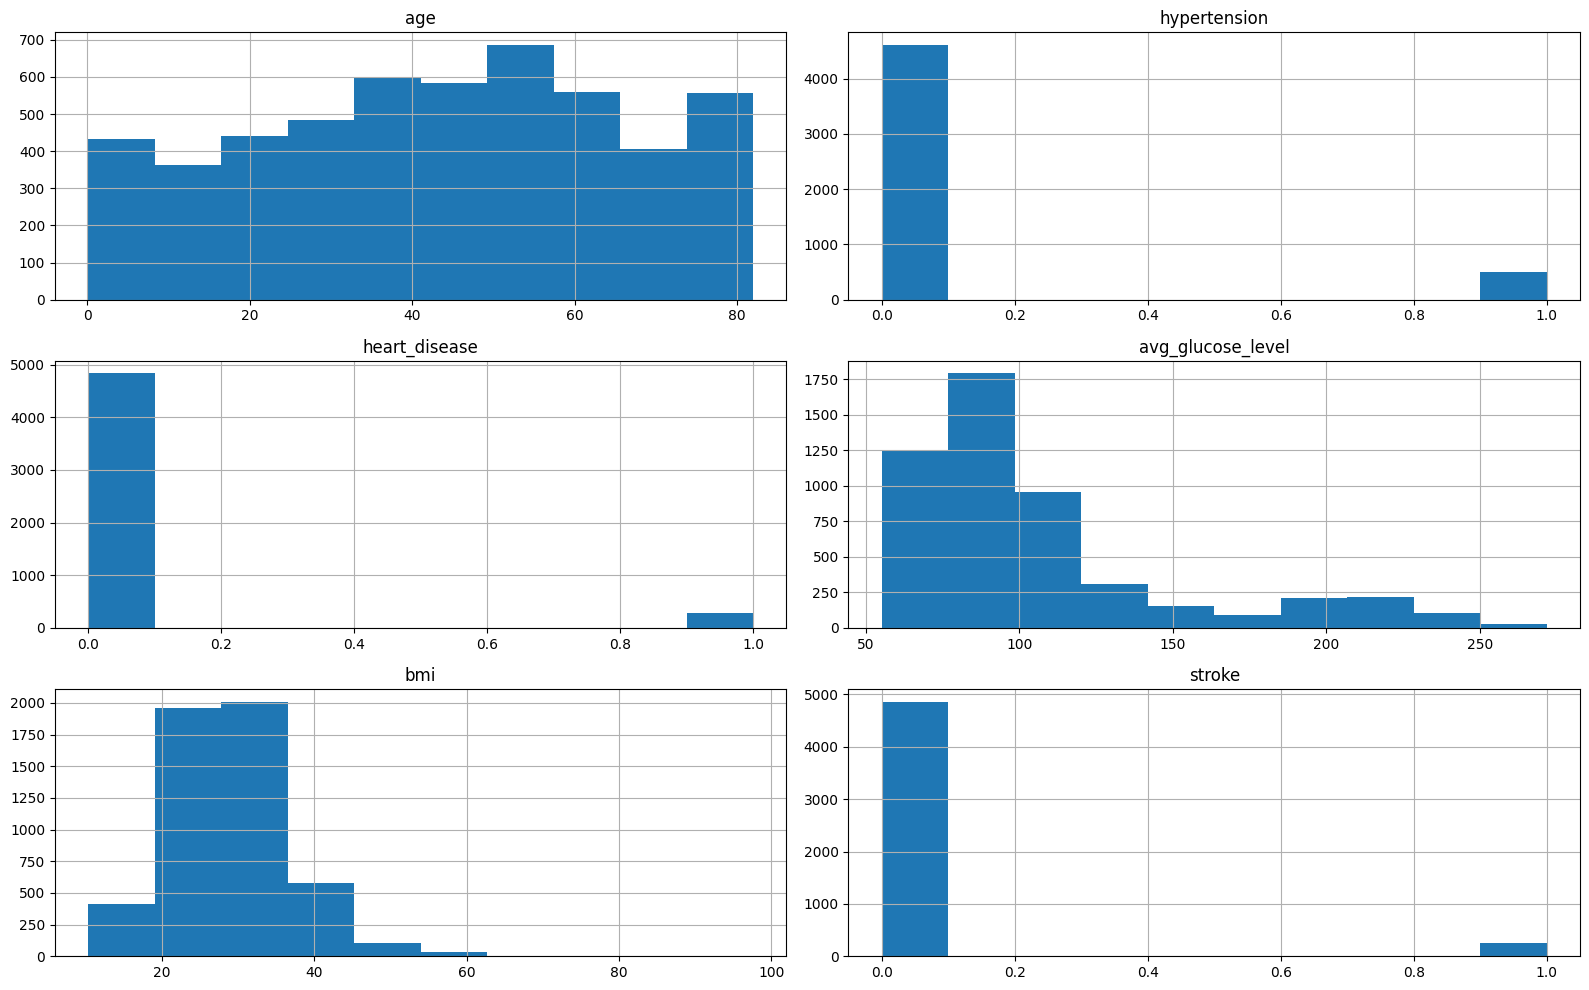

In [ ]:
# Visualize distribution of all numerical columns
# Check for skewness, outliers, and data spread before modeling
df.hist(figsize=(16,10))
plt.tight_layout() # prevent overlapping between subplots(mengatur jarak antar subplot supaya tidak saling tumpang tindih)
plt.savefig("images/histogram_distribution.png",dpi=300, bbox_inches="tight")
plt.show()


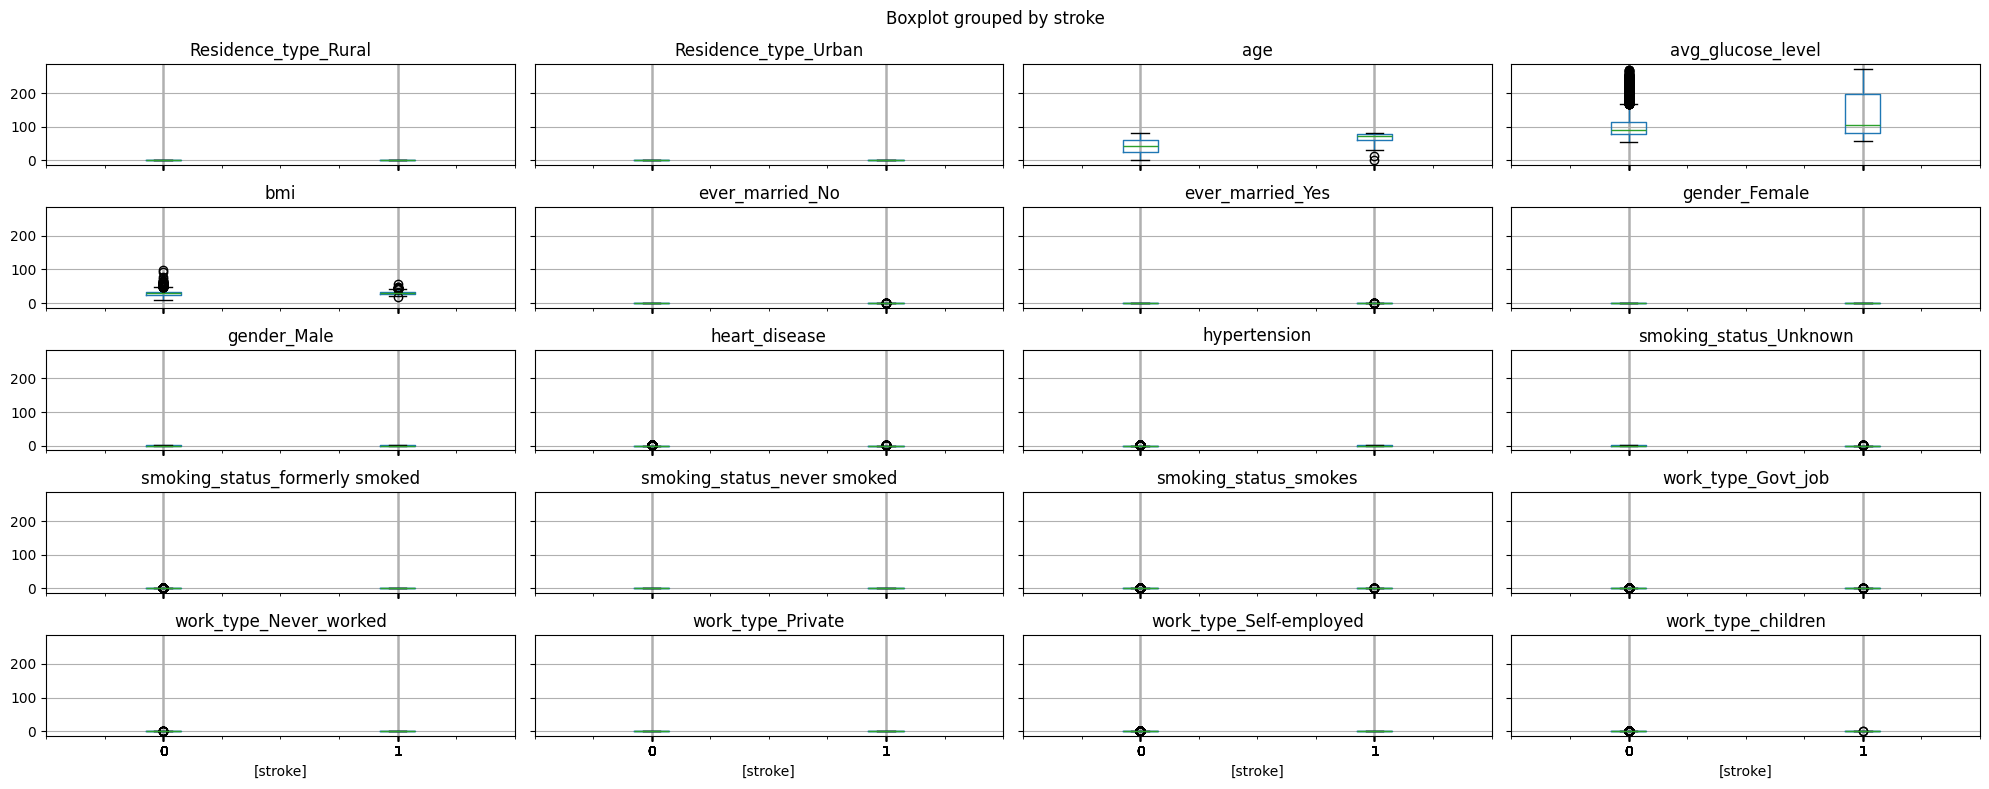

In [ ]:
# Boxplot of all features grouped by stroke status
# Compare distribution between stroke (1) and non-stroke (0) patients
df.boxplot(by='stroke', figsize=(20,8))
plt.tight_layout()
plt.savefig("images/boxplot_by_stroke.png", dpi=300, bbox_inches="tight")
plt.show()

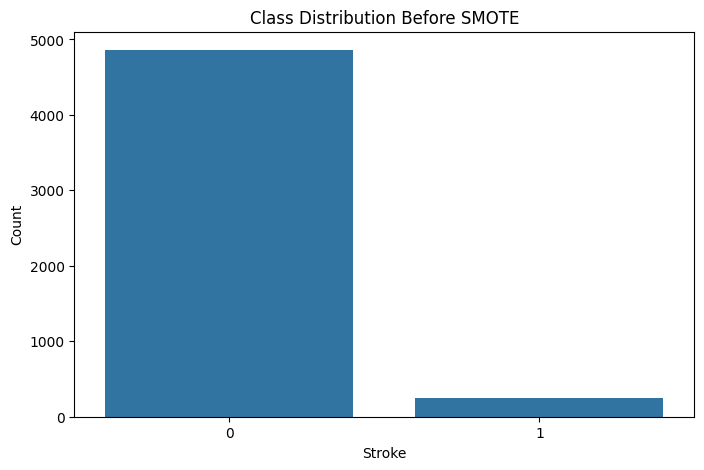

stroke
0    4860
1     249
Name: count, dtype: int64


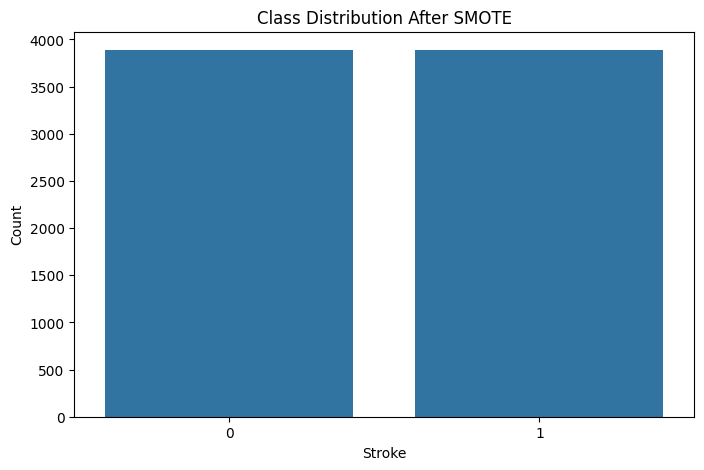

stroke
0    3888
1    3888
Name: count, dtype: int64


In [ ]:
# Separate features (X) and target (y)
X = df.drop('stroke', axis=1)
y = df['stroke']

# Visualize class distribution BEFORE SMOTE
plt.figure(figsize=(8,5))
ax = sns.countplot(x=y)
ax.set_title('Class Distribution Before SMOTE')
ax.set_xlabel('Stroke')
ax.set_ylabel('Count')
plt.savefig("images/class_distribution_before_smote.png", dpi=300, bbox_inches="tight")
plt.show()
print(y.value_counts())

# Split dataset into training and testing set
# Split BEFORE SMOTE to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=10,
                                                      stratify=y)

# Apply SMOTE only on training set
# Prevent data leakage to test set
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

# Visualize class distribution AFTER SMOTE
plt.figure(figsize=(8,5))
ax = sns.countplot(x=y_train)
ax.set_title('Class Distribution After SMOTE')
ax.set_xlabel('Stroke')
ax.set_ylabel('Count')
plt.savefig("images/class_distribution_after_smote.png", dpi=300, bbox_inches="tight")
plt.show()
print(pd.Series(y_train).value_counts())

=== SVM Performance ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


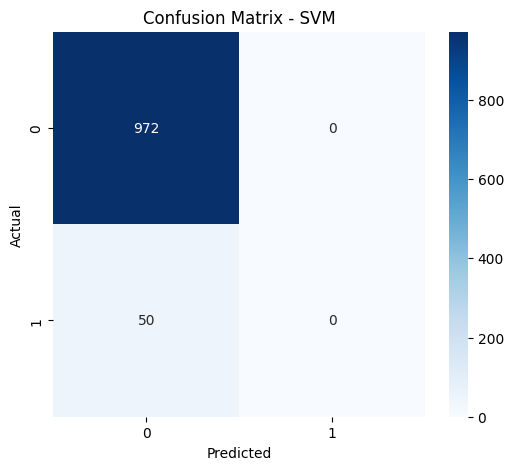

In [ ]:
# Feature Scaling - only for SVM
# SVM is sensitive to feature scale
scaler = StandardScaler()

# Fit only on training set to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM model with linear kernel
model_svc = svm.SVC(kernel='linear', class_weight='balanced')
model_svc.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_svc = model_svc.predict(X_test_scaled)

# Evaluate model performance
print("=== SVM Performance ===")
print(classification_report(y_test, y_pred_svc))

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_svc),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("images/confution_matrix_svm.png", dpi=300, bbox_inches="tight")
plt.show()

=== Bagging Performance ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       972
           1       0.32      0.12      0.17        50

    accuracy                           0.94      1022
   macro avg       0.64      0.55      0.57      1022
weighted avg       0.92      0.94      0.93      1022



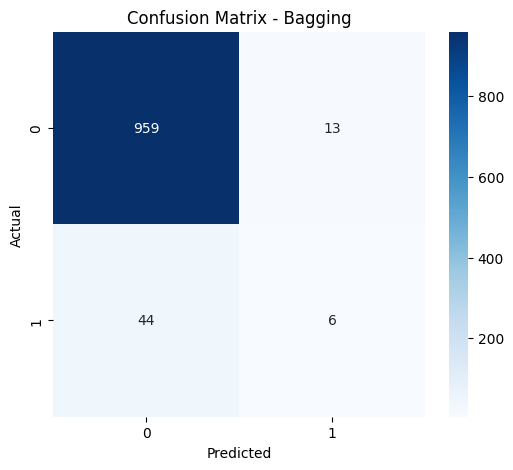

In [ ]:
# Train Bagging model
model_bagging = BaggingClassifier(n_estimators=500, oob_score=True, random_state=10)
model_bagging.fit(X_train, y_train)

# Predict on test set
y_pred_bagging = model_bagging.predict(X_test)

# Evaluate model performance
print("=== Bagging Performance ===")
print(classification_report(y_test, y_pred_bagging))

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test,y_pred_bagging),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Bagging')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("images/confution_matrix_bagging.png", dpi=300, bbox_inches="tight")
plt.show()

=== AdaBoost Performance ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       972
           1       0.20      0.10      0.13        50

    accuracy                           0.94      1022
   macro avg       0.58      0.54      0.55      1022
weighted avg       0.92      0.94      0.93      1022



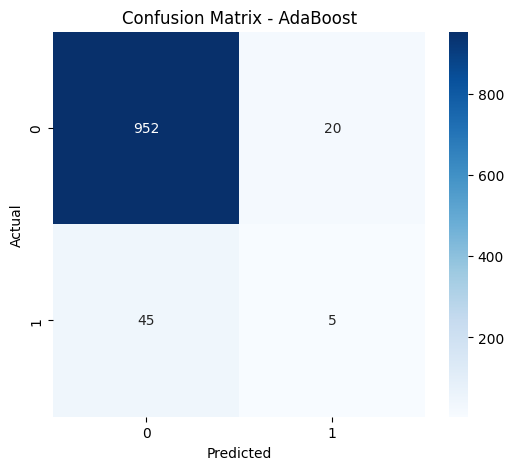

In [ ]:
# Train AdaBoost model
model_ada = AdaBoostClassifier(n_estimators=500,random_state=10)
model_ada.fit(X_train, y_train)

# Predict on test set
y_pred_ada = model_ada.predict(X_test)

# Evaluate model performance
print("=== AdaBoost Performance ===")
print(classification_report(y_test, y_pred_ada))

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_ada),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - AdaBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("images/confution_matrix_adaboost.png", dpi=300, bbox_inches="tight")
plt.show()


=== Model Accuracy Comparison ===
Accuracy SVM     : 0.95
Accuracy Bagging : 0.94
Accuracy AdaBoost: 0.94


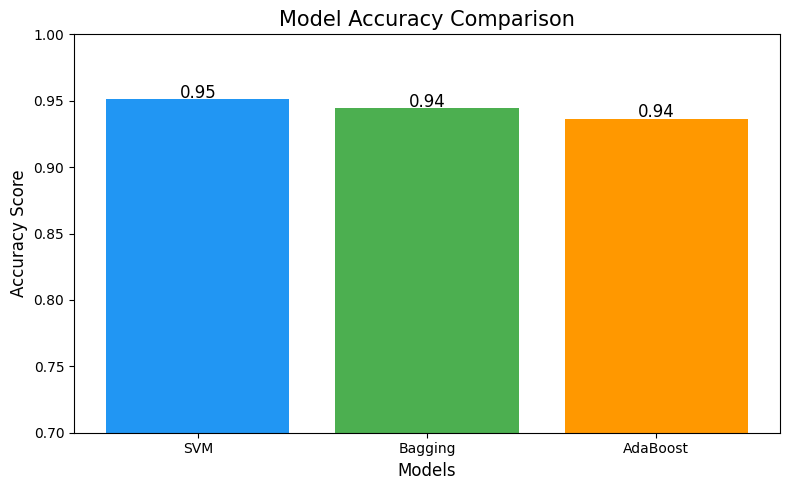

In [ ]:
# Compare accuracy of all three models
print("=== Model Accuracy Comparison ===")
print(f"Accuracy SVM     : {accuracy_score(y_test, y_pred_svc):.2f}")
print(f"Accuracy Bagging : {accuracy_score(y_test, y_pred_bagging):.2f}")
print(f"Accuracy AdaBoost: {accuracy_score(y_test, y_pred_ada):.2f}")

# Visualize accuracy comparison
accuracy_scores = [
    accuracy_score(y_test, y_pred_svc),
    accuracy_score(y_test, y_pred_bagging),
    accuracy_score(y_test, y_pred_ada)
]

plt.figure(figsize=(8,5))
bars = plt.bar(['SVM', 'Bagging', 'AdaBoost'], accuracy_scores,
               color=['#2196F3', '#4CAF50', '#FF9800'])
plt.ylim(0.70, 1.0)
plt.title('Model Accuracy Comparison', fontsize=15)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)

# Tambahkan angka di atas setiap bar
for bar, score in zip(bars, accuracy_scores):
    plt.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 0.001,
             f'{score:.2f}', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig("images/accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Pipeline yang mencakup SMOTE + model
pipeline_bagging = ImbPipeline([
    ('smote', SMOTE(random_state=10)),
    ('model', BaggingClassifier(n_estimators=500, random_state=10))
])

pipeline_ada = ImbPipeline([
    ('smote', SMOTE(random_state=10)),
    ('model', AdaBoostClassifier(n_estimators=500, random_state=10))
])

pipeline_svc = ImbPipeline([
    ('smote', SMOTE(random_state=10)),
    ('scaler', StandardScaler()),
    ('model', svm.SVC(kernel='linear', class_weight='balanced'))
])

# Stratified K-Fold menjaga proporsi kelas di setiap fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# Cross validation
cv_svc = cross_val_score(pipeline_svc, X, y, cv=cv, scoring='f1')
cv_bagging = cross_val_score(pipeline_bagging, X, y, cv=cv, scoring='f1')
cv_ada = cross_val_score(pipeline_ada, X, y, cv=cv, scoring='f1')

print("=== Cross Validation Results (F1 Score) ===")
print(f"SVM CV F1      : {cv_svc.mean():.2f} ± {cv_svc.std():.2f}")
print(f"Bagging CV F1  : {cv_bagging.mean():.2f} ± {cv_bagging.std():.2f}")
print(f"AdaBoost CV F1 : {cv_ada.mean():.2f} ± {cv_ada.std():.2f}")

=== Cross Validation Results (F1 Score) ===
SVM CV F1      : 0.00 ± 0.00
Bagging CV F1  : 0.09 ± 0.04
AdaBoost CV F1 : 0.13 ± 0.05


/tmp/ipykernel_1972/2672509638.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


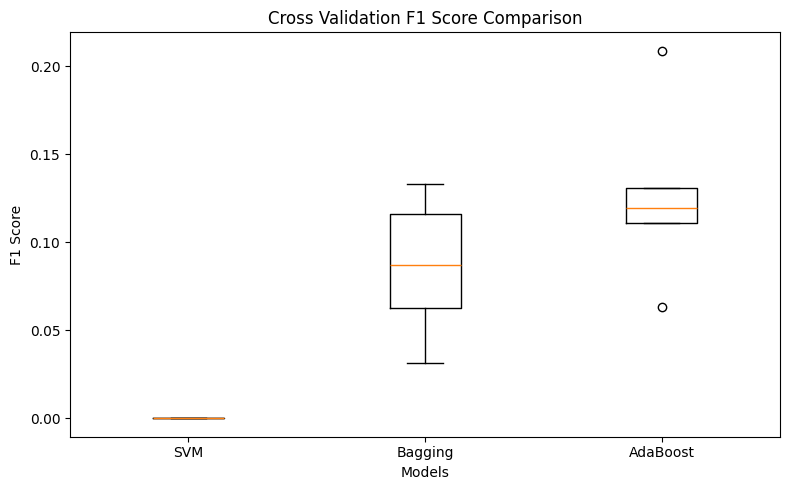

In [ ]:
# Visualize cross validation results
cv_results = {
    'SVM': cv_svc,
    'Bagging': cv_bagging,
    'AdaBoost': cv_ada
}

plt.figure(figsize=(8,5))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title('Cross Validation F1 Score Comparison')
plt.ylabel('F1 Score')
plt.xlabel('Models')
plt.tight_layout()
plt.savefig("images/cross_validation_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ROC AUC untuk setiap model
# predict_proba untuk probabilitas, bukan binary prediction
print("=== ROC AUC Score ===")
print(f"SVM     : {roc_auc_score(y_test, model_svc.decision_function(X_test_scaled)):.2f}")
print(f"Bagging : {roc_auc_score(y_test, model_bagging.predict_proba(X_test)[:,1]):.2f}")
print(f"AdaBoost: {roc_auc_score(y_test, model_ada.predict_proba(X_test)[:,1]):.2f}")

=== ROC AUC Score ===
SVM     : 0.39
Bagging : 0.81
AdaBoost: 0.84


In [ ]:
# CV dengan ROC AUC
cv_svc_auc = cross_val_score(pipeline_svc, X, y,
                              cv=cv, scoring='roc_auc')
cv_bagging_auc = cross_val_score(pipeline_bagging, X, y,
                                  cv=cv, scoring='roc_auc')
cv_ada_auc = cross_val_score(pipeline_ada, X, y,
                              cv=cv, scoring='roc_auc')

print("=== Cross Validation ROC AUC ===")
print(f"SVM CV AUC      : {cv_svc_auc.mean():.2f} ± {cv_svc_auc.std():.2f}")
print(f"Bagging CV AUC  : {cv_bagging_auc.mean():.2f} ± {cv_bagging_auc.std():.2f}")
print(f"AdaBoost CV AUC : {cv_ada_auc.mean():.2f} ± {cv_ada_auc.std():.2f}")

=== Cross Validation ROC AUC ===
SVM CV AUC      : 0.57 ± 0.05
Bagging CV AUC  : 0.79 ± 0.03
AdaBoost CV AUC : 0.81 ± 0.01


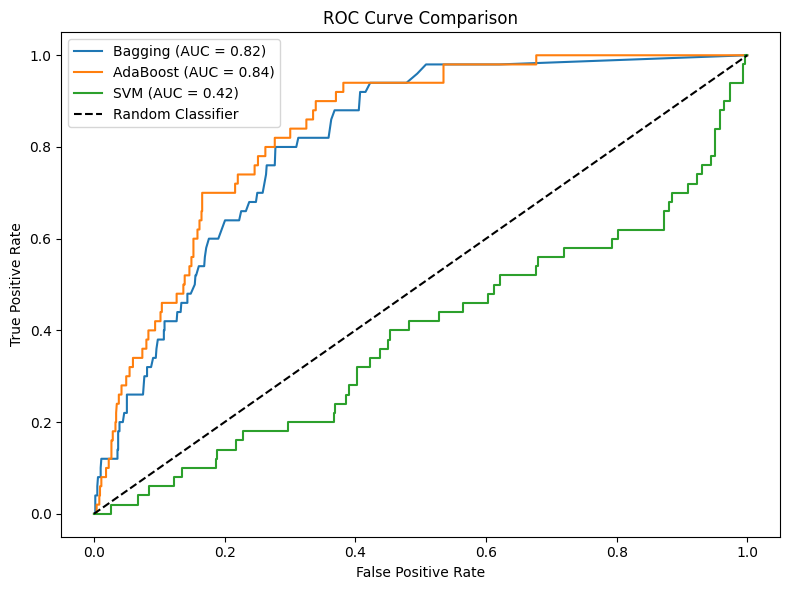

In [ ]:
plt.figure(figsize=(8,6))

# Bagging
fpr_b, tpr_b, _ = roc_curve(y_test,
                   model_bagging.predict_proba(X_test)[:,1])
plt.plot(fpr_b, tpr_b,
         label=f'Bagging (AUC = 0.82)')

# AdaBoost
fpr_a, tpr_a, _ = roc_curve(y_test,
                   model_ada.predict_proba(X_test)[:,1])
plt.plot(fpr_a, tpr_a,
         label=f'AdaBoost (AUC = 0.84)')

# SVM
fpr_s, tpr_s, _ = roc_curve(y_test,
                   model_svc.decision_function(X_test_scaled))
plt.plot(fpr_s, tpr_s,
         label=f'SVM (AUC = 0.42)')

# Garis random classifier
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig("images/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

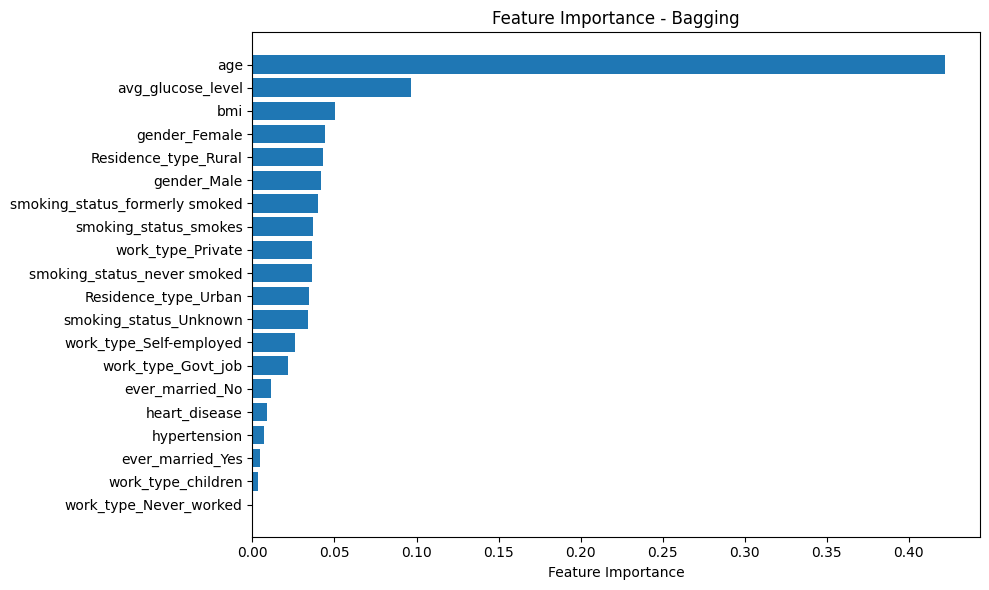

=== Top 5 Most Important Features (Bagging) ===
                  fitur  importance
0                   age    0.422358
3     avg_glucose_level    0.096586
4                   bmi    0.050457
5         gender_Female    0.044337
9  Residence_type_Rural    0.043091


In [ ]:
# Calculate average feature importance from all 500 trees
# Hitung rata-rata feature importance dari semua 500 pohon
all_importances = []
for pohon in model_bagging.estimators_:
    all_importances.append(pohon.feature_importances_)

importances = np.mean(all_importances, axis=0)

# Create feature importance dataframe
feature_names = X.columns
fi_df = pd.DataFrame({
    'fitur': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Visualize feature importance
plt.figure(figsize=(10,6))
plt.barh(fi_df['fitur'], fi_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Bagging')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("images/feature_importance_bagging.png", dpi=300, bbox_inches="tight")
plt.show()

# Print top 5 most important features
print("=== Top 5 Most Important Features (Bagging) ===")
print(fi_df.head())

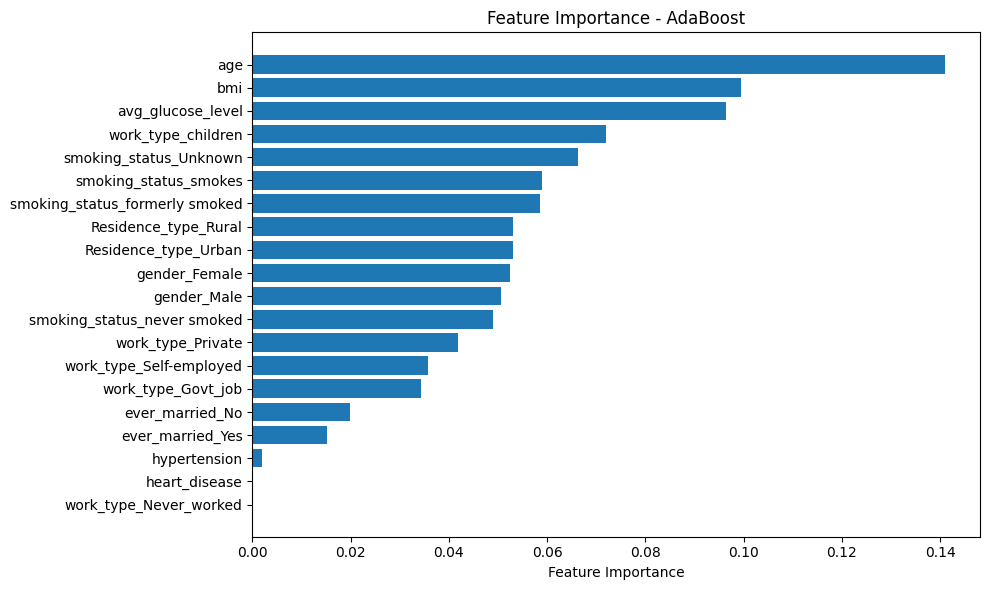

=== Top 5 Most Important Features (AdaBoost) ===
                     fitur  importance
0                      age    0.141075
4                      bmi    0.099558
3        avg_glucose_level    0.096322
15      work_type_children    0.072069
16  smoking_status_Unknown    0.066318


In [ ]:
# Get feature importance from AdaBoost
# AdaBoost has built-in feature_importances_ attribute
importances_ada = model_ada.feature_importances_

# Create feature importance dataframe
fi_ada_df = pd.DataFrame({
    'fitur': X.columns,
    'importance': importances_ada
}).sort_values('importance', ascending=False)

# Visualize feature importance
plt.figure(figsize=(10,6))
plt.barh(fi_ada_df['fitur'], fi_ada_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance - AdaBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("images/feature_importance_adaboost.png", dpi=300, bbox_inches="tight")
plt.show()

# Print top 5 most important features
print("=== Top 5 Most Important Features (AdaBoost) ===")
print(fi_ada_df.head())


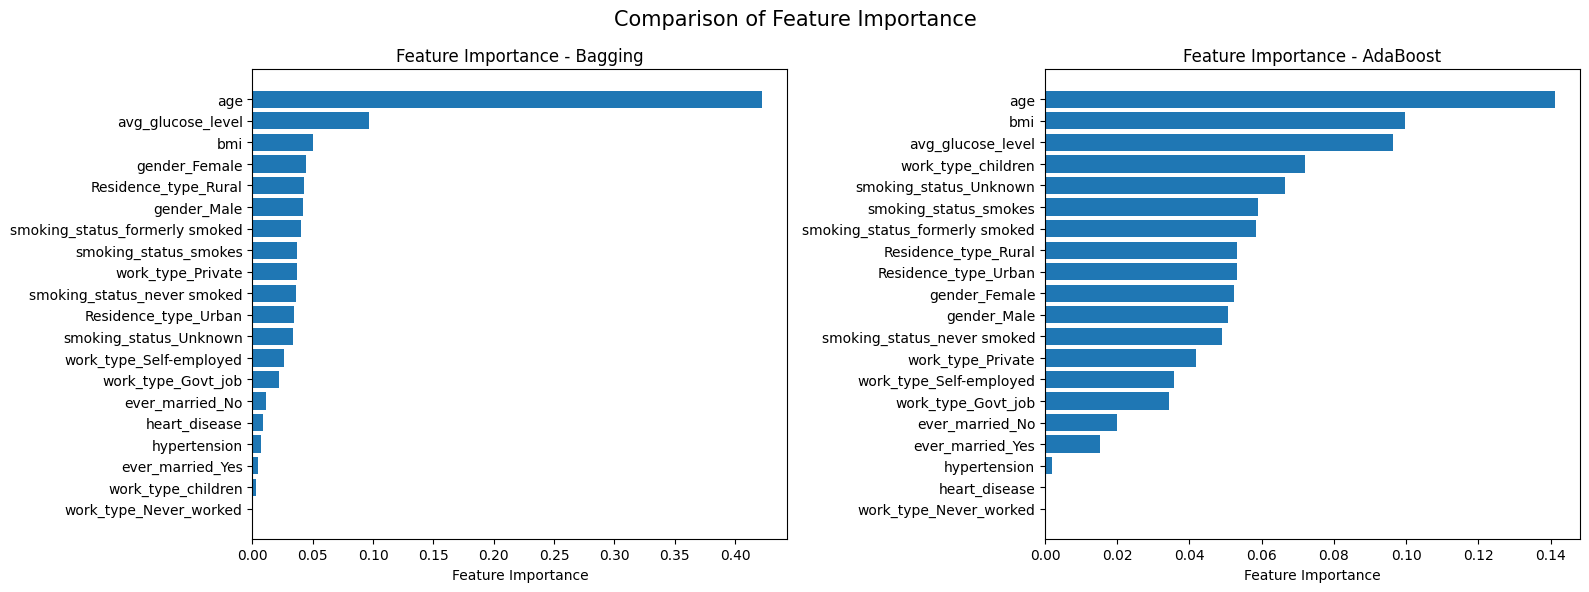

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Bagging
ax1.barh(fi_df['fitur'], fi_df['importance'])
ax1.set_title('Feature Importance - Bagging')
ax1.set_xlabel('Feature Importance')
ax1.invert_yaxis()

# AdaBoost
ax2.barh(fi_ada_df['fitur'], fi_ada_df['importance'])
ax2.set_title('Feature Importance - AdaBoost')
ax2.set_xlabel('Feature Importance')
ax2.invert_yaxis()

plt.suptitle('Comparison of Feature Importance', fontsize=15)
plt.tight_layout()
plt.savefig("images/feature_importance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()